<div style="background: linear-gradient(90deg, #2c3e50, #3498db); 
            padding: 20px; border-radius: 10px; text-align:center;">
    <h1 style="color:white; font-family:Trebuchet MS, sans-serif; font-size:40px;">
        📊 Machine Learning Analysis 🚀
    </h1>
    <p style="color:#ecf0f1; font-size:18px; margin-top:10px; text-align:center;">
        Feature Scaling in SciKit-Learn (Normalization vs Standardization)
    </p>
</div>


In [97]:
import pandas as pd 
import numpy as np 
import warnings 
warnings.filterwarnings("ignore")

In [98]:
ns = pd.read_csv("500hits.csv", encoding="latin1")

In [122]:
ns.head(4).style.background_gradient(cmap="Dark2") \
  .format("{:.2f}")

,YRS,G,AB,R,H,2B,3B,HR,RBI,BB,SO,SB,CS,BA
0,24.00,3035.00,11434.00,2246.00,4189.00,724.00,295.00,117.00,726.00,1249.00,357.00,892.00,178.00,0.37
1,22.00,3026.00,10972.00,1949.00,3630.00,725.00,177.00,475.00,1951.00,1599.00,696.00,78.00,31.00,0.33
2,22.00,2789.00,10195.00,1882.00,3514.00,792.00,222.00,117.00,724.00,1381.00,220.00,432.00,129.00,0.34
3,20.00,2747.00,11195.00,1923.00,3465.00,544.00,66.00,260.00,1311.00,1082.00,1840.00,358.00,97.00,0.31


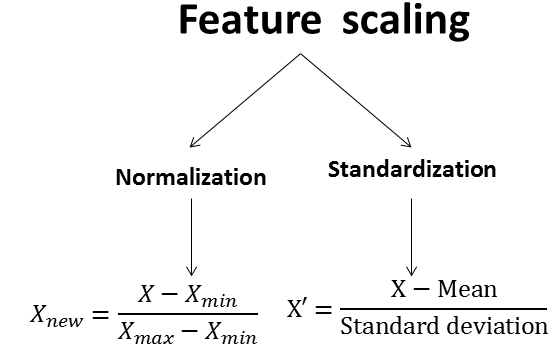

In [100]:
ns = ns.drop(columns =["PLAYER","HOF"])

In [101]:
ns.info()
# ns.dtypes

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 465 entries, 0 to 464
Data columns (total 14 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   YRS     465 non-null    int64  
 1   G       465 non-null    int64  
 2   AB      465 non-null    int64  
 3   R       465 non-null    int64  
 4   H       465 non-null    int64  
 5   2B      465 non-null    int64  
 6   3B      465 non-null    int64  
 7   HR      465 non-null    int64  
 8   RBI     465 non-null    int64  
 9   BB      465 non-null    int64  
 10  SO      465 non-null    int64  
 11  SB      465 non-null    int64  
 12  CS      465 non-null    int64  
 13  BA      465 non-null    float64
dtypes: float64(1), int64(13)
memory usage: 51.0 KB


In [126]:
ns.describe().round(2).style.background_gradient(cmap="cool") 

,YRS,G,AB,R,H,2B,3B,HR,RBI,BB,SO,SB,CS,BA
count,465.000000,465.000000,465.000000,465.000000,465.000000,465.000000,465.000000,465.000000,465.000000,465.000000,465.000000,465.000000,465.000000,465.000000
mean,17.050000,2048.700000,7511.460000,1150.310000,2170.250000,380.950000,78.550000,201.050000,894.260000,783.560000,847.470000,195.910000,58.080000,0.290000
std,2.770000,354.390000,1294.070000,289.640000,424.190000,96.480000,49.360000,143.620000,486.190000,327.430000,489.220000,181.850000,48.030000,0.020000
min,11.000000,1331.000000,4981.000000,601.000000,1660.000000,177.000000,3.000000,9.000000,0.000000,239.000000,0.000000,7.000000,0.000000,0.250000
25%,15.000000,1802.000000,6523.000000,936.000000,1838.000000,312.000000,41.000000,79.000000,640.000000,535.000000,436.000000,63.000000,22.000000,0.270000
50%,17.000000,1993.000000,7241.000000,1104.000000,2076.000000,366.000000,67.000000,178.000000,968.000000,736.000000,825.000000,137.000000,52.000000,0.290000
75%,19.000000,2247.000000,8180.000000,1296.000000,2375.000000,436.000000,107.000000,292.000000,1206.000000,955.000000,1226.000000,285.000000,84.000000,0.300000
max,26.000000,3308.000000,12364.000000,2295.000000,4189.000000,792.000000,309.000000,755.000000,2297.000000,2190.000000,2597.000000,1406.000000,335.000000,0.370000


In [103]:
ns.columns

Index(['YRS', 'G', 'AB', 'R', 'H', '2B', '3B', 'HR', 'RBI', 'BB', 'SO', 'SB',
       'CS', 'BA'],
      dtype='object')

In [104]:
X1 = ns.iloc[:, 0:13]

In [105]:
y1 = ns.iloc[:,-1]

In [106]:
from sklearn.preprocessing import StandardScaler

#### We always perform Feature Scaling in Training set.

In [107]:
ss = StandardScaler()

In [108]:
X1 = ss.fit_transform(X1)

In [109]:
# Suppose your raw data has 14 columns, but you only want 13 features
columns = ['YRS', 'G', 'AB', 'R', 'H', '2B', '3B',
           'HR', 'RBI', 'BB', 'SO', 'SB', 'CS']

X1 = pd.DataFrame(X1, columns=columns)   # features


In [129]:
X1.head().style.background_gradient(cmap="Set2") \
  .format("{:.2f}")

,YRS,G,AB,R,H,2B,3B,HR,RBI,BB,SO,SB,CS
0,2.52,2.79,3.03,3.79,4.76,3.56,4.39,-0.59,-0.35,1.42,-1.00,3.83,2.50
1,1.79,2.76,2.68,2.76,3.44,3.57,2.00,1.91,2.18,2.49,-0.31,-0.65,-0.56
2,1.79,2.09,2.08,2.53,3.17,4.26,2.91,-0.59,-0.35,1.83,-1.28,1.30,1.48
3,1.07,1.97,2.85,2.67,3.06,1.69,-0.25,0.41,0.86,0.91,2.03,0.89,0.81
4,1.43,2.10,2.26,2.02,2.97,2.69,3.52,-0.70,-1.84,0.55,-1.07,2.90,-0.90


In [130]:
X1.describe().round(2).style.background_gradient(cmap="Dark2") \
  .format("{:.2f}")

,YRS,G,AB,R,H,2B,3B,HR,RBI,BB,SO,SB,CS
count,465.000000,465.000000,465.000000,465.000000,465.000000,465.000000,465.000000,465.000000,465.000000,465.000000,465.000000,465.000000,465.000000
mean,-0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,-0.000000,-0.000000,0.000000,0.000000,-0.000000,0.000000,-0.000000
std,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
min,-2.190000,-2.030000,-1.960000,-1.900000,-1.200000,-2.120000,-1.530000,-1.340000,-1.840000,-1.660000,-1.730000,-1.040000,-1.210000
25%,-0.740000,-0.700000,-0.760000,-0.740000,-0.780000,-0.720000,-0.760000,-0.850000,-0.520000,-0.760000,-0.840000,-0.730000,-0.750000
50%,-0.020000,-0.160000,-0.210000,-0.160000,-0.220000,-0.160000,-0.230000,-0.160000,0.150000,-0.150000,-0.050000,-0.320000,-0.130000
75%,0.710000,0.560000,0.520000,0.500000,0.480000,0.570000,0.580000,0.630000,0.640000,0.520000,0.770000,0.490000,0.540000
max,3.240000,3.560000,3.750000,3.960000,4.760000,4.260000,4.670000,3.860000,2.890000,4.300000,3.580000,6.660000,5.770000


In [112]:
X2 = ns.iloc[:,0:13]

In [113]:
from sklearn.preprocessing import MinMaxScaler #Normalizaion

In [114]:
mm = MinMaxScaler(feature_range=(0,1))

In [115]:
X2 = mm.fit_transform(X2)

In [116]:
# Suppose your raw data has 14 columns, but you only want 13 features
columns = ['YRS', 'G', 'AB', 'R', 'H', '2B', '3B',
           'HR', 'RBI', 'BB', 'SO', 'SB', 'CS']

X2 = pd.DataFrame(X2, columns=columns)   # features

In [117]:
X2.head(3)

,YRS,G,AB,R,H,2B,3B,HR,RBI,BB,SO,SB,CS
0,0.866667,0.861912,0.874035,0.971074,1.000000,0.889431,0.954248,0.144772,0.316064,0.517683,0.137466,0.632595,0.531343
1,0.733333,0.857360,0.811459,0.795750,0.778964,0.891057,0.568627,0.624665,0.849369,0.697078,0.268002,0.050751,0.092537
2,0.733333,0.737481,0.706217,0.756198,0.733096,1.000000,0.715686,0.144772,0.315194,0.585341,0.084713,0.303788,0.385075


In [132]:
X2.describe().round(2).style.background_gradient(cmap="cool") \
  .format("{:.2f}")

,YRS,G,AB,R,H,2B,3B,HR,RBI,BB,SO,SB,CS
count,465.00,465.00,465.00,465.00,465.00,465.00,465.00,465.00,465.00,465.00,465.00,465.00,465.00
mean,0.40,0.36,0.34,0.32,0.20,0.33,0.25,0.26,0.39,0.28,0.33,0.14,0.17
std,0.18,0.18,0.18,0.17,0.17,0.16,0.16,0.19,0.21,0.17,0.19,0.13,0.14
min,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
25%,0.27,0.24,0.21,0.20,0.07,0.22,0.12,0.09,0.28,0.15,0.17,0.04,0.07
50%,0.40,0.33,0.31,0.30,0.16,0.31,0.21,0.23,0.42,0.25,0.32,0.09,0.16
75%,0.53,0.46,0.43,0.41,0.28,0.42,0.34,0.38,0.53,0.37,0.47,0.20,0.25
max,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00


In [133]:
X1.describe().round(2).style.background_gradient(cmap="Set1") \
  .format("{:.2f}")

,YRS,G,AB,R,H,2B,3B,HR,RBI,BB,SO,SB,CS
count,465.00,465.00,465.00,465.00,465.00,465.00,465.00,465.00,465.00,465.00,465.00,465.00,465.00
mean,-0.00,0.00,0.00,0.00,0.00,0.00,-0.00,-0.00,0.00,0.00,-0.00,0.00,-0.00
std,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00
min,-2.19,-2.03,-1.96,-1.90,-1.20,-2.12,-1.53,-1.34,-1.84,-1.66,-1.73,-1.04,-1.21
25%,-0.74,-0.70,-0.76,-0.74,-0.78,-0.72,-0.76,-0.85,-0.52,-0.76,-0.84,-0.73,-0.75
50%,-0.02,-0.16,-0.21,-0.16,-0.22,-0.16,-0.23,-0.16,0.15,-0.15,-0.05,-0.32,-0.13
75%,0.71,0.56,0.52,0.50,0.48,0.57,0.58,0.63,0.64,0.52,0.77,0.49,0.54
max,3.24,3.56,3.75,3.96,4.76,4.26,4.67,3.86,2.89,4.30,3.58,6.66,5.77


<div style="background-color:#f9f9f9; border-top:6px solid #3498db; 
            padding:20px; border-radius:8px; text-align:center; margin-top:40px;">
    <h2 style="color:#2c3e50; font-family:Arial, sans-serif;">
        ✅ End of Notebook
    </h2>
    <p style="font-size:16px; color:#34495e;text-align:center;">
        Thank you for reviewing this analysis.<br>
        🚀 Keep experimenting, keep learning!
    </p>
</div>
